<a href="https://colab.research.google.com/github/Hattot888/AML-model/blob/main/AML_Abdulrahman_Hattem_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imoprts

In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score

import matplotlib.pyplot as plt
import seaborn as sns

# Uplodes

In [2]:
df = pd.read_csv('/content/paysim.csv')

In [3]:
# Preview Dataset
print("Dataset Preview:")
display(df.head())

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Class Distribution
print("\nFraud Distribution:")
print(df['isFraud'].value_counts())

print("\nFraud Percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)


Dataset Preview:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287568 entries, 0 to 287567
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            287568 non-null  int64  
 1   type            287568 non-null  object 
 2   amount          287568 non-null  float64
 3   nameOrig        287568 non-null  object 
 4   oldbalanceOrg   287568 non-null  float64
 5   newbalanceOrig  287568 non-null  float64
 6   nameDest        287567 non-null  object 
 7   oldbalanceDest  287567 non-null  float64
 8   newbalanceDest  287567 non-null  float64
 9   isFraud         287567 non-null  float64
 10  isFlaggedFraud  287567 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 24.1+ MB
None

Statistical Summary:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,287568.000000,2.875680e+05,2.875680e+05,2.875680e+05,2.875670e+05,2.875670e+05,287567.000000,287567.0
mean,11.287629,1.768339e+05,8.828152e+05,9.015769e+05,9.722454e+05,1.196402e+06,0.000616,0.0
std,2.588137,3.046953e+05,2.822913e+06,2.860450e+06,2.365799e+06,2.597810e+06,0.024802,0.0
min,1.000000,3.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.267318e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,11.000000,7.694082e+04,1.875400e+04,0.000000e+00,8.158400e+04,1.841253e+05,0.000000,0.0
75%,13.000000,2.314142e+05,1.846476e+05,2.226594e+05,8.468607e+05,1.237963e+06,0.000000,0.0
max,15.000000,1.000000e+07,3.893942e+07,3.894623e+07,4.133844e+07,4.138365e+07,1.000000,0.0



Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64

Fraud Distribution:
isFraud
0.0    287390
1.0       177
Name: count, dtype: int64

Fraud Percentage:
isFraud
0.0    99.938449
1.0     0.061551
Name: proportion, dtype: float64


In [4]:
# Drop Unnecessary Columns
df = df.drop(['nameOrig', 'nameDest','isFlaggedFraud'], axis=1)

df = df.dropna()

# One-Hot Encoding
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Feature / Target Split
X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nPreprocessing Completed Successfully!")
print("Scaled Feature Shape:", X_scaled.shape)


Preprocessing Completed Successfully!
Scaled Feature Shape: (287567, 10)


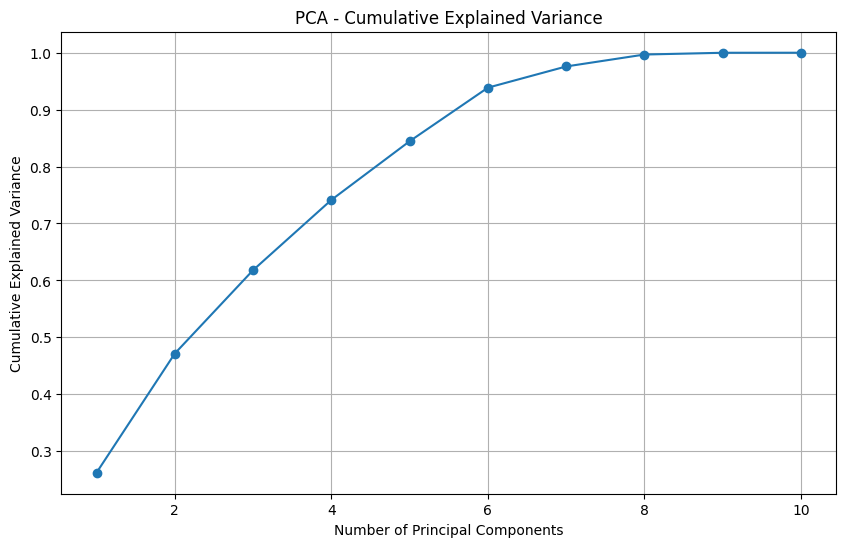

Optimal Number of Components: 7
Reduced Dataset Shape: (287567, 7)


In [5]:



#  APPLY PCA (ALL COMPONENTS)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)


#  EXPLAINED VARIANCE

explained_variance = pca.explained_variance_ratio_

cumulative_variance = explained_variance.cumsum()


#  PLOT CUMULATIVE VARIANCE

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('PCA - Cumulative Explained Variance')

plt.grid(True)

plt.show()


#  ELECT OPTIMAL COMPONENTS


n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Optimal Number of Components: {n_components}")


#  FINAL PCA TRANSFORMATION


pca_final = PCA(n_components=n_components)

X_pca_final = pca_final.fit_transform(X_scaled)

print("Reduced Dataset Shape:", X_pca_final.shape)

Sample Shape: (10000, 7)


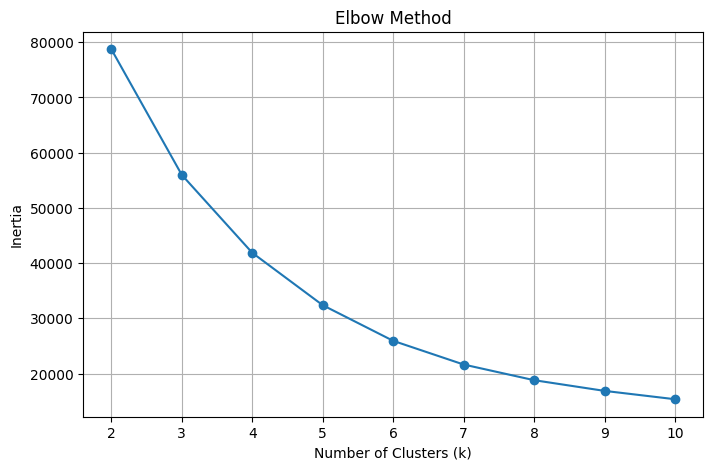

In [6]:

#  FAST K-MEANS CLUSTERING


from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np


#  TAKE SMALL SAMPLE


sample_size = 10000

X_sample = X_pca_final[:sample_size]

print("Sample Shape:", X_sample.shape)


#  ELBOW METHOD


inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_sample)

    inertia.append(kmeans.inertia_)

#  Plot Elbow

plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.grid(True)

plt.show()





--- Classification Report ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     57479
         1.0       0.61      0.66      0.63        35

    accuracy                           1.00     57514
   macro avg       0.80      0.83      0.81     57514
weighted avg       1.00      1.00      1.00     57514



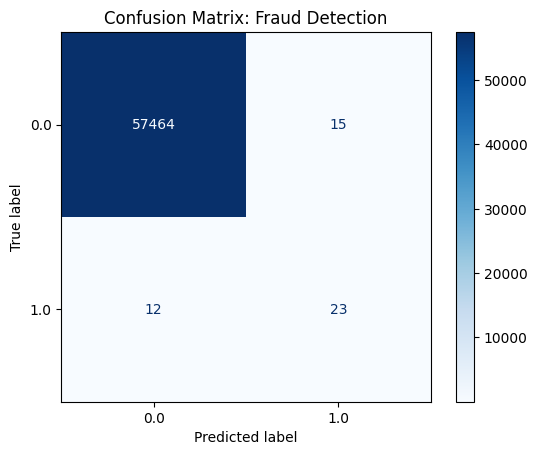

In [9]:


# 1. Create df_final and add behavioral segments

df_final = df.copy()

kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42, n_init=10)
# Apply clustering to the entire PCA dataset (X_pca_final)

df_final['behavioral_segment'] = kmeans.fit_predict(X_pca_final)

# 2. Prepare features and target

X_final = pd.DataFrame(X_scaled).copy()
X_final['behavioral_segment'] = df_final['behavioral_segment'].values
y_final = df_final['isFraud']

# 3. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# 4. Train XGBoost Model

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=99,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

# 5. Evaluation

y_pred = model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix: Fraud Detection')
plt.show()

In [15]:
# =========================================================
# CONTINUOUS LEARNING (BATCH UPDATE SIMULATION)
# =========================================================


# =========================================================
# Simulate New Incoming Data (Next Month Batch)
# =========================================================

# نأخذ جزء صغير من الداتا كأنه "new data"
new_data_size = int(0.1 * len(X_train))

X_new = X_train[-new_data_size:]
y_new = y_train[-new_data_size:]

X_old = X_train[:-new_data_size]
y_old = y_train[:-new_data_size]

# =========================================================
# Train Initial Model (Old Data Only)
# =========================================================

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=100,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_old, y_old)

print("Initial Model Trained on Old Data")

# =========================================================
# Update Model with New Data (Incremental Learning)
# =========================================================

model.fit(
    X_new,
    y_new,
    xgb_model=model.get_booster()
)

print("Model Updated with New Data Batch")

# =========================================================
#  Evaluate Updated Model
# =========================================================

y_pred_updated = model.predict(X_test)

from sklearn.metrics import f1_score, recall_score, precision_score

print("\nUpdated Model Performance:")

print("F1 Score:", f1_score(y_test, y_pred_updated))
print("Recall:", recall_score(y_test, y_pred_updated))
print("Precision:", precision_score(y_test, y_pred_updated))

Initial Model Trained on Old Data
Model Updated with New Data Batch

Updated Model Performance:
F1 Score: 0.6296296296296297
Recall: 0.4857142857142857
Precision: 0.8947368421052632
